# BNN Classification on Two Moons using ```bayesian-torch```

In this project, we utilize the classic Two Moons dataset to demonstrate uncertainty quantification using variational Bayesian neural networks through the ```bayesian-torch``` library.

In [11]:
from pathlib import Path
import sys
import time
import os
import copy
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd().resolve()
while ROOT != ROOT.parent and not (ROOT / 'shared').exists():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from bayesian_torch.models.dnn_to_bnn import dnn_to_bnn, get_kl_loss
from bayesian_torch.utils.avuc_loss import AvULoss
from shared import TinyMLP, checkpoint_exists, load_checkpoint, save_checkpoint, load_two_moons, seed_everything, train_map
from shared import standard_metrics

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

SEED = 42
seed_everything(SEED)

FIGURES_DIR = os.path.join('..', 'figures')
os.makedirs(FIGURES_DIR, exist_ok=True)

checkpoint_dir = str(ROOT / "results" / "checkpoints" / "two_moons_bayesian_1seed")
os.makedirs(checkpoint_dir, exist_ok=True)

plt.rcParams.update({
    "font.family": "serif",
    "font.size": 12,
    "savefig.dpi": 150,
    "savefig.bbox": "tight",
})

Device: cuda


In [12]:
# Data / Grid
data = load_two_moons(seed=SEED, noise=0.3, batch_train=32, batch_eval=64, device=device)
X_train = data["X_train"]
X_val   = data["X_val"]
X_test  = data["X_test"]
y_train = data["y_train"]
y_val   = data["y_val"]
y_test  = data["y_test"]
train_ds = data["train_ds"]
train_loader = data["train_loader"]
val_loader   = data["val_loader"]
test_loader  = data["test_loader"]
X_test_tensor = data["X_test_tensor"]

y_test_np  = y_test

# Visualization helpers 
def plot_boundary(predict_fn, X_data, y_data, title, ax=None):
    """predict_fn: (N,2) numpy -> (N,) class-1 probs"""
    h = 0.05
    x_min, x_max = X_data[:, 0].min() - 0.5, X_data[:, 0].max() + 0.5
    y_min, y_max = X_data[:, 1].min() - 0.5, X_data[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
    grid = np.c_[xx.ravel(), yy.ravel()]
    probs = predict_fn(grid).reshape(xx.shape)
    if ax is None:
        _, ax = plt.subplots(figsize=(5, 4))
    cf = ax.contourf(xx, yy, probs, levels=50, cmap="RdBu_r", alpha=0.8, vmin=0, vmax=1)
    ax.contour(xx, yy, probs, levels=[0.5], colors="k", linewidths=1.5)
    ax.scatter(X_data[:, 0], X_data[:, 1], c=y_data, cmap="bwr",
               edgecolors="k", linewidths=0.4, s=30, zorder=3)
    ax.set_title(title)
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    return cf, probs

def uncertainty_map(predict_fn, X_data, y_data, title, ax):
    """Uncertainty = 1 - confidence = 1 - max(p, 1-p), matching the table metric (range [0, 0.5])."""
    h = 0.05
    x_min, x_max = X_data[:, 0].min() - 0.5, X_data[:, 0].max() + 0.5
    y_min, y_max = X_data[:, 1].min() - 0.5, X_data[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
    grid = np.c_[xx.ravel(), yy.ravel()]
    probs = predict_fn(grid).reshape(xx.shape)
    uncertainty = 1 - np.maximum(probs, 1 - probs)  # = 1 - confidence
    cf = ax.contourf(xx, yy, uncertainty, levels=50, cmap="YlOrRd", vmin=0, vmax=0.5)
    ax.scatter(X_data[:, 0], X_data[:, 1], c=y_data, cmap="bwr",
               edgecolors="k", linewidths=0.4, s=30, zorder=3)
    ax.set_title(title)
    return cf, uncertainty

def plot_reliability(labels, probs, ax, title, n_bins=15):
    """Reliability / calibration diagram. probs: (N,2)."""
    conf = probs.max(axis=1)
    preds = probs.argmax(axis=1)
    accs_bin, confs_bin = [], []
    for i in range(n_bins):
        lo, hi = i / n_bins, (i + 1) / n_bins
        mask = (conf > lo) & (conf <= hi)
        if mask.sum() == 0:
            continue
        accs_bin.append((preds[mask] == labels[mask]).mean())
        confs_bin.append(conf[mask].mean())
    ax.plot([0, 1], [0, 1], "k--", label="Perfect calibration")
    ax.plot(confs_bin, accs_bin, "o-", label="Model")
    ax.set_xlabel("Mean Confidence")
    ax.set_ylabel("Accuracy")
    ax.set_title(title)
    ax.legend()
    ax.grid(True, alpha=0.3)

# Bayesian predict wrappers (MC sampling — the bayesian-torch analog of la_predict)
def bnn_predict_samples(X_np, model, n_samples=100, batch_size=512):
    """Return stacked MC probability samples of shape (S, N, C)."""
    model.eval()
    parts = []
    with torch.no_grad():
        for i in range(0, len(X_np), batch_size):
            X_t = torch.tensor(X_np[i:i + batch_size], dtype=torch.float32).to(device)
            sims = [torch.softmax(model(X_t), dim=1).cpu().numpy() for _ in range(n_samples)]
            parts.append(np.stack(sims))            # (S, b, C)
    return np.concatenate(parts, axis=1)            # (S, N, C)

def bnn_predict(X_np, model, n_samples=30):
    """Mean class-1 probability over MC samples (matches plot_boundary's predict_fn API)."""
    return bnn_predict_samples(X_np, model, n_samples=n_samples).mean(axis=0)[:, 1]

# Train / load the deterministic MAP net (used to warm-start the MOPED variants)
map_ckpt = str(ROOT / "results" / "checkpoints" / f"two_moons_map_seed{SEED}.pt")  # shared with the Bayesian notebook
map_model, map_losses, map_fit_time = train_map(
    TinyMLP(hidden=64).to(device), train_loader,
    epochs=300, checkpoint_path=map_ckpt, device=device
)
map_model.eval()

# Appreciate the parameter doubling: deterministic DNN -> variational BNN (mu + rho per weight)
det_params = sum(p.numel() for p in map_model.parameters())
_probe = TinyMLP(hidden=64).to(device)
dnn_to_bnn(_probe, {"prior_mu": 0.0, "prior_sigma": 1.0, "posterior_mu_init": 0.0,
                    "posterior_rho_init": -3.0, "type": "Reparameterization",
                    "moped_enable": False, "moped_delta": 0.5})
bnn_params = sum(p.numel() for p in _probe.parameters() if p.requires_grad)
print(f"MAP ready (fit_time={map_fit_time:.1f}s)")
print(f"Deterministic params: {det_params:,}  ->  BNN params: {bnn_params:,}  ({bnn_params / det_params:.1f}x)")

# variant_results is populated by the run-all-variants cell below
variant_results = {}

MAP ready (fit_time=33.6s)
Deterministic params: 4,482  ->  BNN params: 8,964  (2.0x)


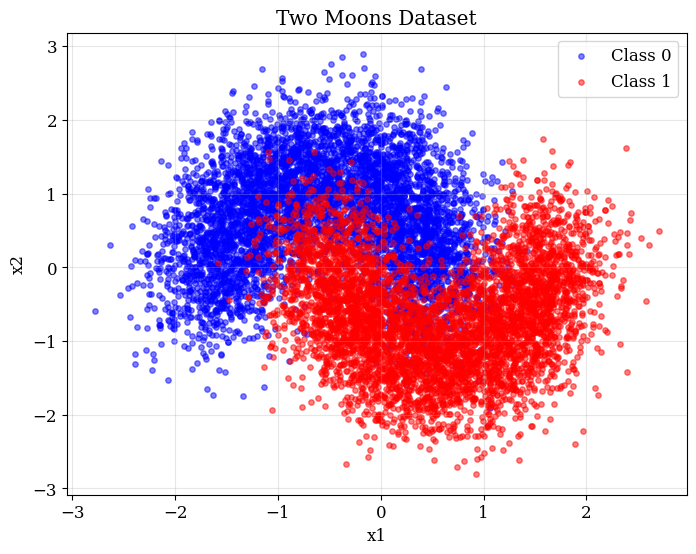

In [13]:
# Dataset Visualization
X_all, y_all = data["X"], data["y"]
fig, ax = plt.subplots(1, 1, figsize=(8, 6))
ax.scatter(X_all[y_all == 0, 0], X_all[y_all == 0, 1], c="blue", alpha=0.5, s=15, label="Class 0")
ax.scatter(X_all[y_all == 1, 0], X_all[y_all == 1, 1], c="red",  alpha=0.5, s=15, label="Class 1")
ax.set_xlabel("x1")
ax.set_ylabel("x2")
ax.set_title("Two Moons Dataset")
ax.legend()
ax.grid(True, alpha=0.3)
fig.savefig(os.path.join(FIGURES_DIR, "dataset_scatter.png"), dpi=150, bbox_inches="tight")
plt.show()

In [14]:
def build_bnn(model_type, moped=False, moped_delta=0.5):
    """Convert a fresh TinyMLP to a BNN. If moped=True, warm-start the posterior
    means from the trained MAP net (MOPED / empirical-Bayes initialisation)."""
    net = TinyMLP(hidden=64).to(device)
    if moped:
        net.load_state_dict(map_model.state_dict())   # warm start from the MAP solution
    bnn_prior_parameters = {
        "prior_mu": 0.0,
        "prior_sigma": 1.0,
        "posterior_mu_init": 0.0,
        "posterior_rho_init": -3.0,
        "type": model_type,
        "moped_enable": moped,
        "moped_delta": moped_delta,
    }
    dnn_to_bnn(net, bnn_prior_parameters)
    return net.to(device)


def _val_nll(net, n_samples=10):
    """Mean predictive NLL on the validation set (the early-stopping criterion)."""
    val_probs = bnn_predict_samples(X_val, net, n_samples=n_samples).mean(axis=0)
    vp = np.clip(val_probs, 1e-12, 1.0)
    return float(-np.log(vp[np.arange(len(y_val)), y_val]).mean())


def fit_or_load_variant(spec):
    vname = spec["variant_name"]
    checkpoint_path = os.path.join(checkpoint_dir, f"two_moons_{vname}_seed{SEED}.pt")
    net = build_bnn(spec["model_type"], moped=spec["moped"], moped_delta=spec.get("moped_delta", 0.5))

    if checkpoint_exists(checkpoint_path):
        ckpt = load_checkpoint(checkpoint_path, map_location="cpu")
        if isinstance(ckpt, dict) and "model_state_dict" in ckpt:
            net.load_state_dict(ckpt["model_state_dict"])
            return net.to(device), ckpt.get("metrics", {}), checkpoint_path, True

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(net.parameters(), lr=spec["lr"])
    max_epochs = spec["epochs"]
    patience = spec.get("patience", 25)
    num_samples = len(train_ds)
    use_avuc = spec["loss"] == "avuc"
    avu_loss_fn = AvULoss(beta=spec.get("avu_beta", 1.0)) if use_avuc else None
    n_mc = 5   # MC samples used to form the predictive for the AvUC term

    # KL term (the Bayesian regularizer) + early stopping on validation NLL guard overfitting.
    best_val, best_state, wait, ran_epochs = float("inf"), None, 0, 0
    fit_start = time.time()
    for epoch in range(max_epochs):
        net.train()
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            if use_avuc:
                logits_mc = torch.stack([net(inputs) for _ in range(n_mc)], dim=0)  # (M, B, C)
                mean_logits = logits_mc.mean(dim=0)
                ce = criterion(mean_logits, labels)
                kl = get_kl_loss(net) / num_samples
                probs = torch.softmax(mean_logits, dim=1)
                ent = -(probs * torch.log(probs + 1e-12)).sum(dim=1)
                thr = ent.mean().item()                       # per-batch uncertainty threshold
                avu = avu_loss_fn(mean_logits, labels, thr, type=0).squeeze()
                loss = ce + kl + avu
            else:
                logits = net(inputs)
                loss = criterion(logits, labels) + get_kl_loss(net) / num_samples
            loss.backward()
            optimizer.step()
        ran_epochs = epoch + 1

        val_nll = _val_nll(net)
        if val_nll < best_val - 1e-4:
            best_val, best_state, wait = val_nll, copy.deepcopy(net.state_dict()), 0
        else:
            wait += 1
            if wait >= patience:
                break

    if best_state is not None:
        net.load_state_dict(best_state)        # restore best-validation weights
    fit_time = time.time() - fit_start

    variant_metrics = {
        "Model_Type": spec["model_type"],
        "Init": "MOPED" if spec["moped"] else "scratch",
        "Loss": "ELBO+AvUC" if use_avuc else "ELBO",
        "Epochs": ran_epochs,
        "Best_Val_NLL": best_val,
        "LR": spec["lr"],
        "Fit_Time (s)": fit_time,
    }
    save_checkpoint({"model_state_dict": net.state_dict(), "metrics": variant_metrics}, checkpoint_path)
    return net, variant_metrics, checkpoint_path, False


# Variant grid: layer Type x Init (scratch/MOPED) x Loss (ELBO / ELBO+AvUC) = 8 variants
variant_specs = []
for model_type, short in [("Flipout", "Flipout"), ("Reparameterization", "BBB")]:
    for moped in [False, True]:
        init = "moped" if moped else "scratch"
        for loss in ["elbo", "avuc"]:
            variant_specs.append({
                "variant_name": f"{short.lower()}_{init}_{loss}",
                "model_type": model_type,
                "moped": moped,
                "moped_delta": 0.5,
                "loss": loss,
                "epochs": 100 if moped else 300,   # cap (same as MAP for scratch); early stopping ends sooner
                "patience": 25,
                "lr": 5e-3,
                "avu_beta": 1.0,
                "plot_title": f"{short} / {init} / {'AvUC' if loss == 'avuc' else 'ELBO'}",
            })

variant_results = {}
variant_eval_rows = []
print(f"Configured {len(variant_specs)} BNN variants (Type x Init x Loss).")

Configured 8 BNN variants (Type x Init x Loss).


In [15]:
# Run all BNN variants -> build variant_eval_df
variant_eval_rows = []
for spec in variant_specs:
    vname = spec["variant_name"]
    print(f"  Training/loading: {vname}")
    net, v_metrics, ckpt_path, from_cache = fit_or_load_variant(spec)
    v_metrics = dict(v_metrics)

    inf_start = time.time()
    samples = bnn_predict_samples(X_test, net, n_samples=50)   # (S, N, C)
    v_test_probs = samples.mean(axis=0)                         # (N, C)
    v_metrics["Inf_Time (s)"] = time.time() - inf_start

    row = {**v_metrics, **standard_metrics(v_test_probs, y_test_np)}
    variant_eval_rows.append(row)
    variant_results[vname] = {"model": net, "probs": v_test_probs, "metrics": row}

variant_eval_df = pd.DataFrame(
    variant_eval_rows,
    index=[s["plot_title"] for s in variant_specs]
)
variant_eval_df.index.name = "Variant"
print(f"\nEvaluated {len(variant_eval_rows)} variants.")

  Training/loading: flipout_scratch_elbo
  Training/loading: flipout_scratch_avuc
  Training/loading: flipout_moped_elbo
  Training/loading: flipout_moped_avuc


  Training/loading: bbb_scratch_elbo
  Training/loading: bbb_scratch_avuc
  Training/loading: bbb_moped_elbo
  Training/loading: bbb_moped_avuc

Evaluated 8 variants.


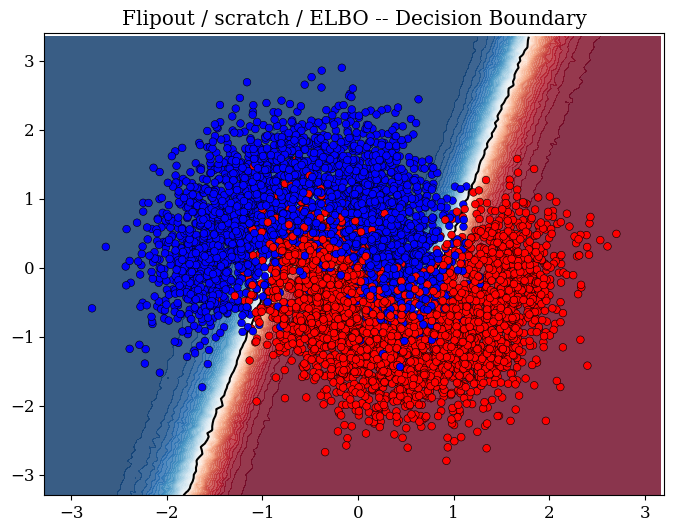

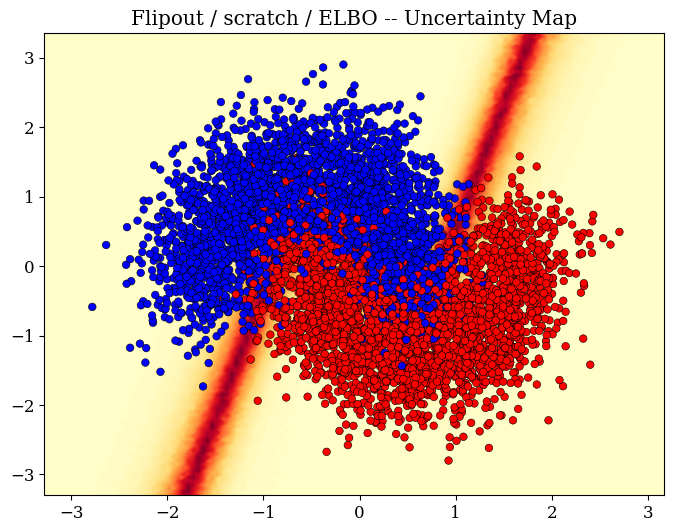

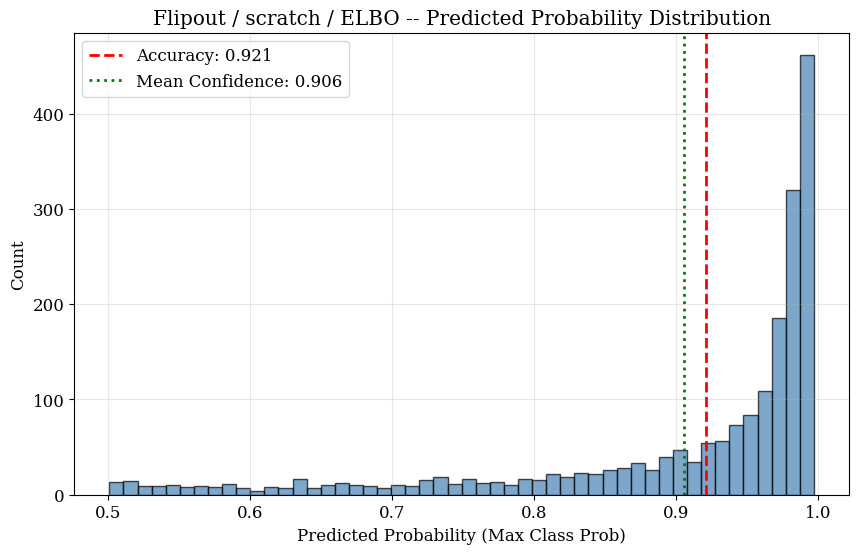

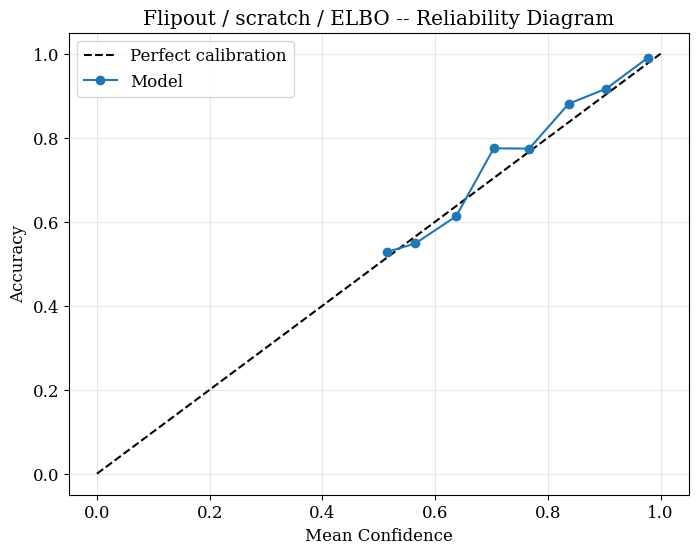

  Saved 4 figures for: flipout_scratch_elbo


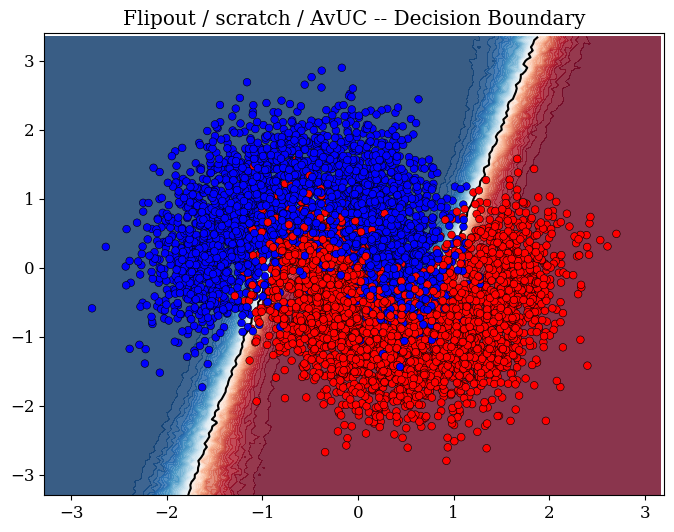

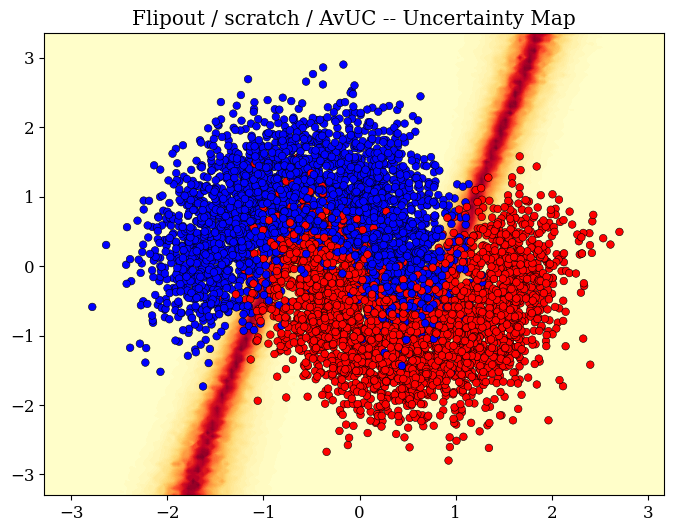

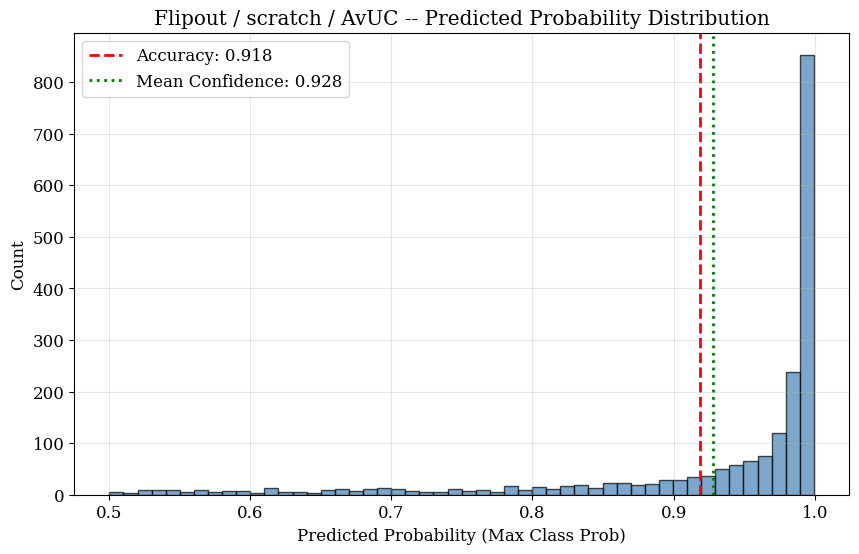

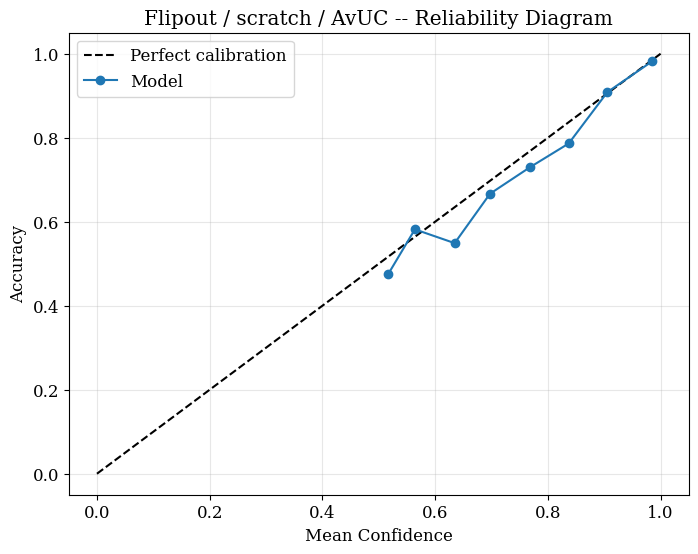

  Saved 4 figures for: flipout_scratch_avuc


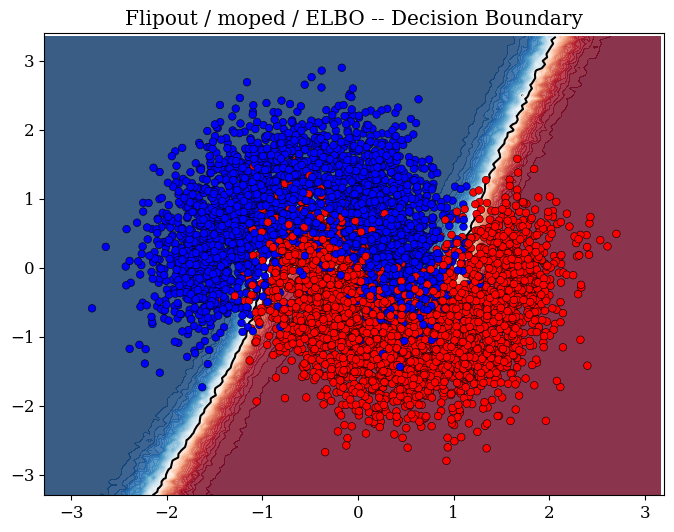

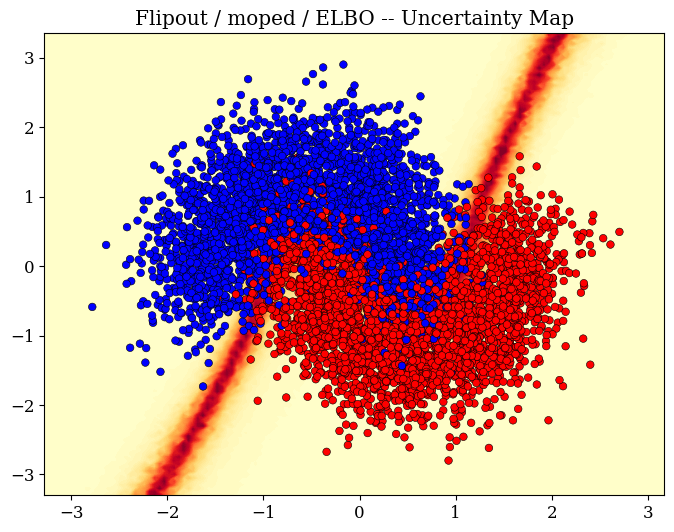

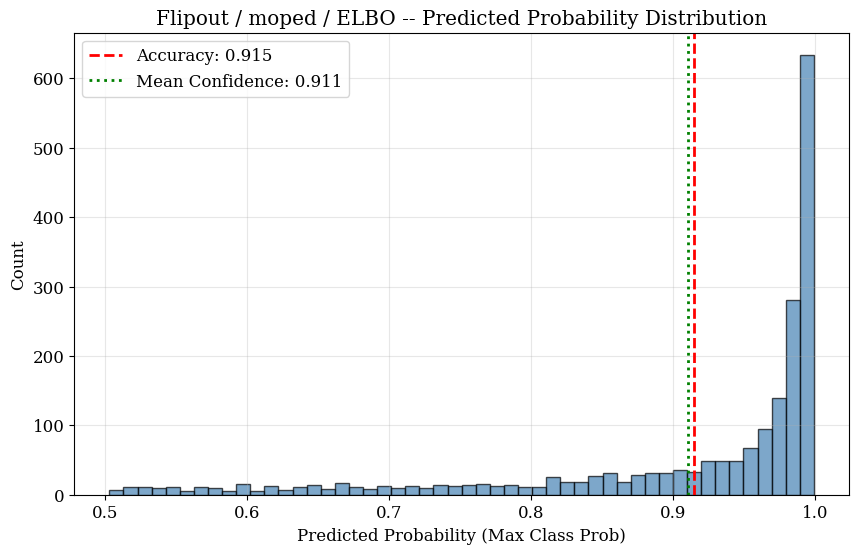

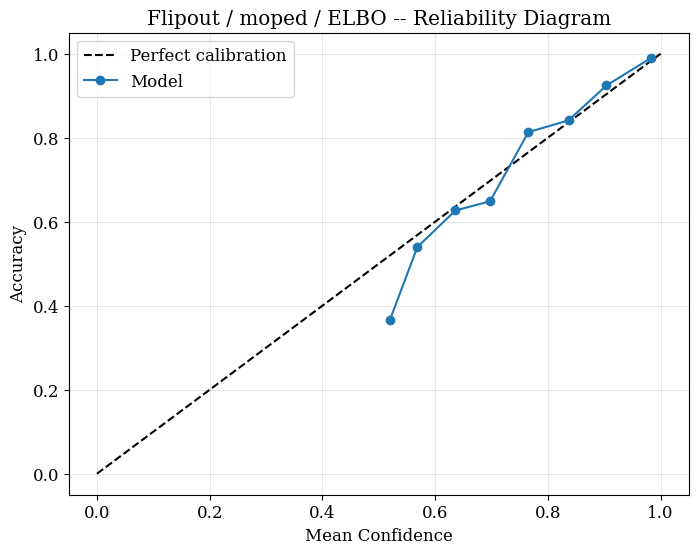

  Saved 4 figures for: flipout_moped_elbo


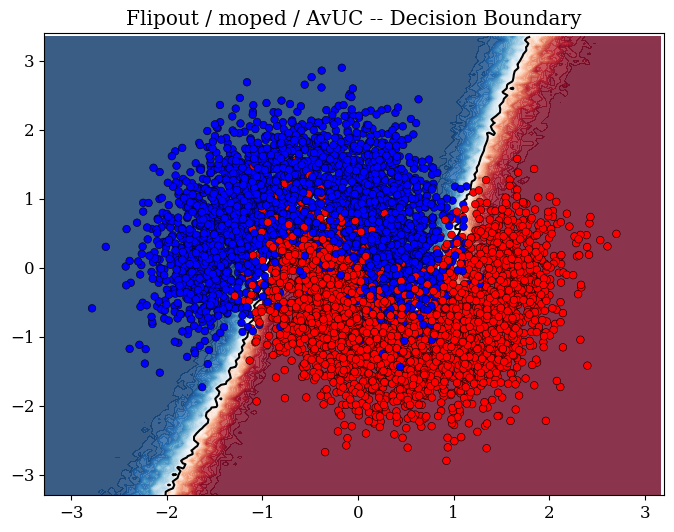

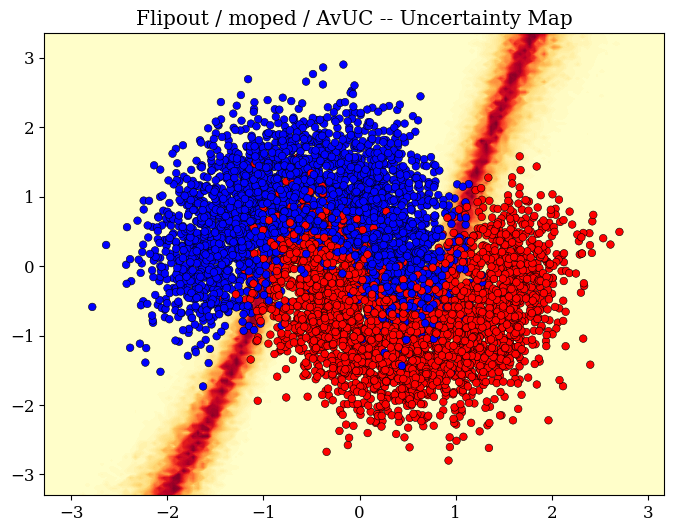

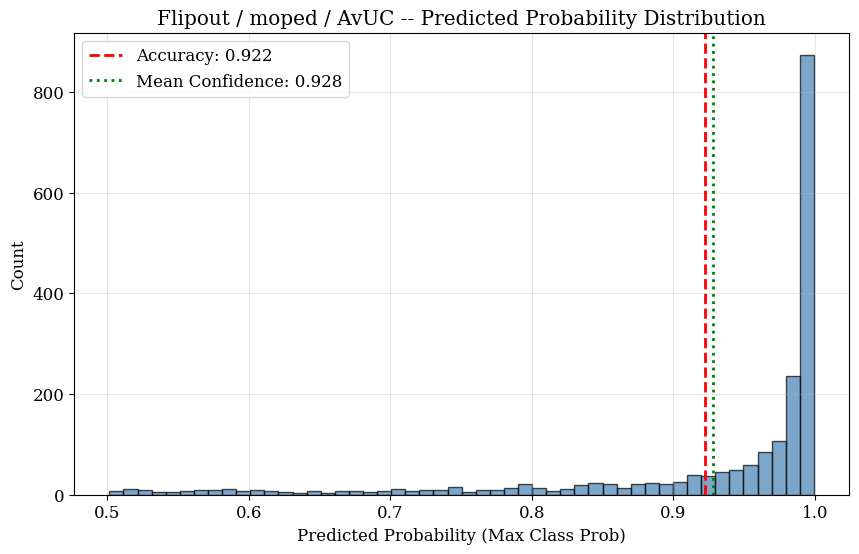

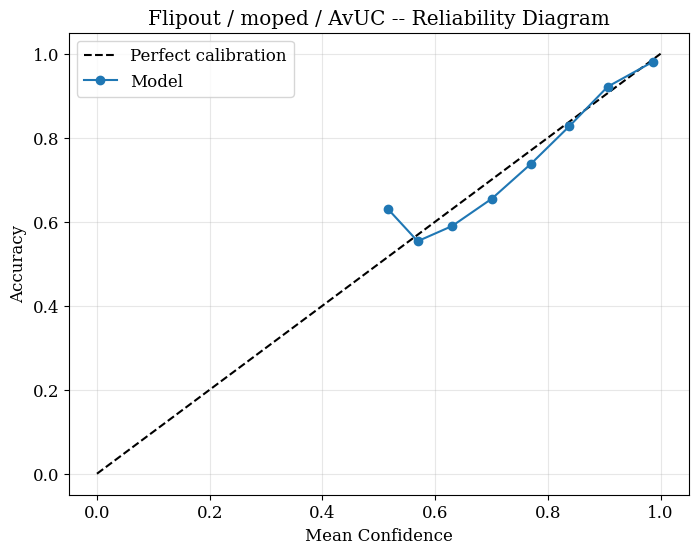

  Saved 4 figures for: flipout_moped_avuc


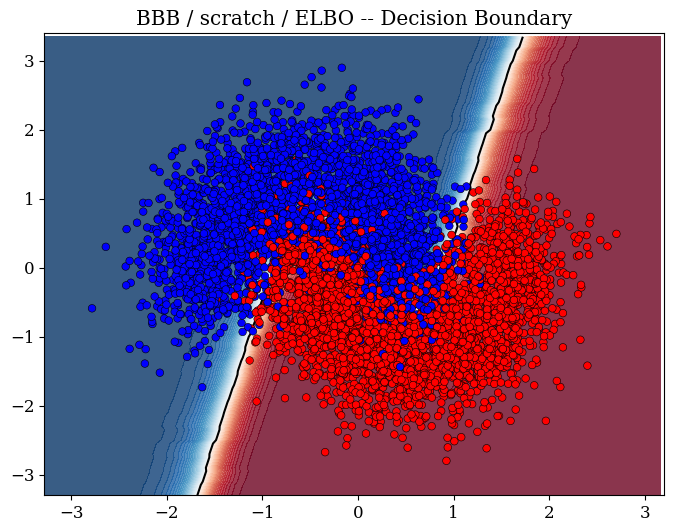

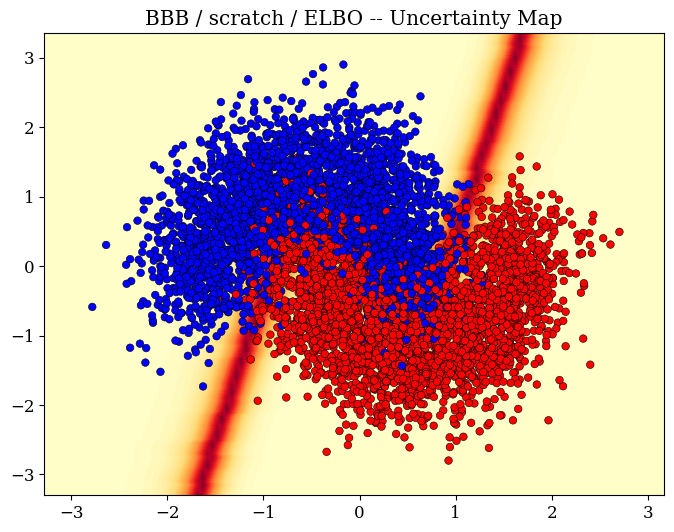

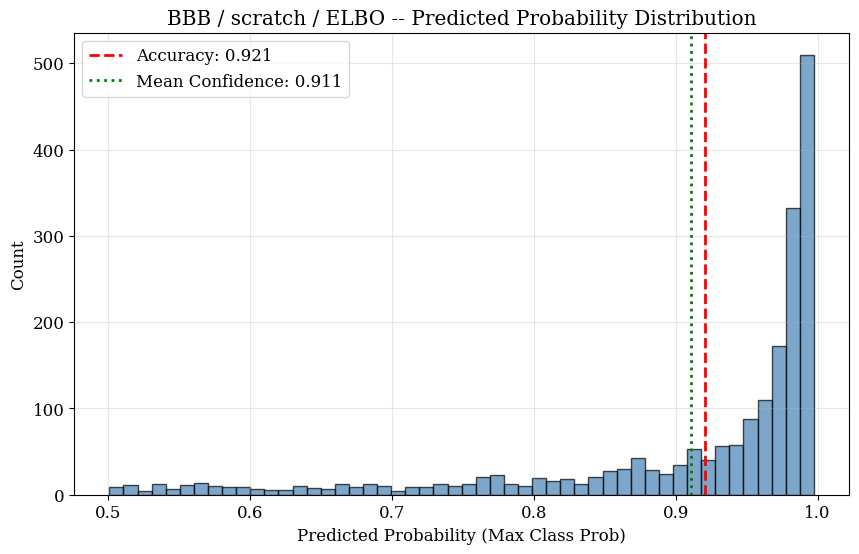

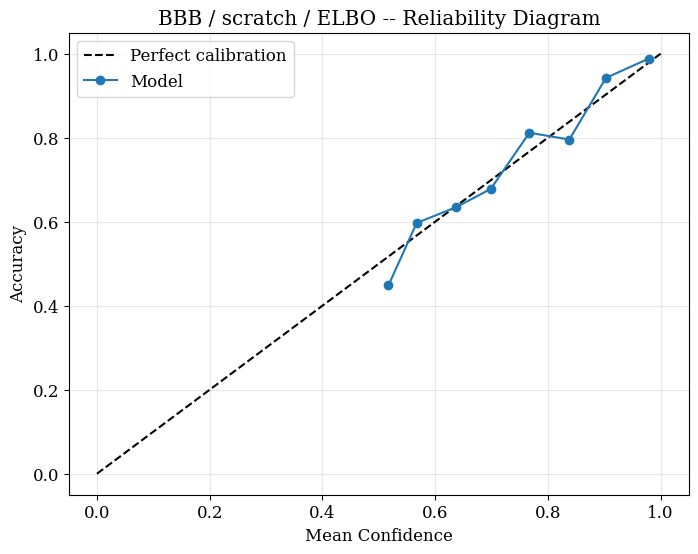

  Saved 4 figures for: bbb_scratch_elbo


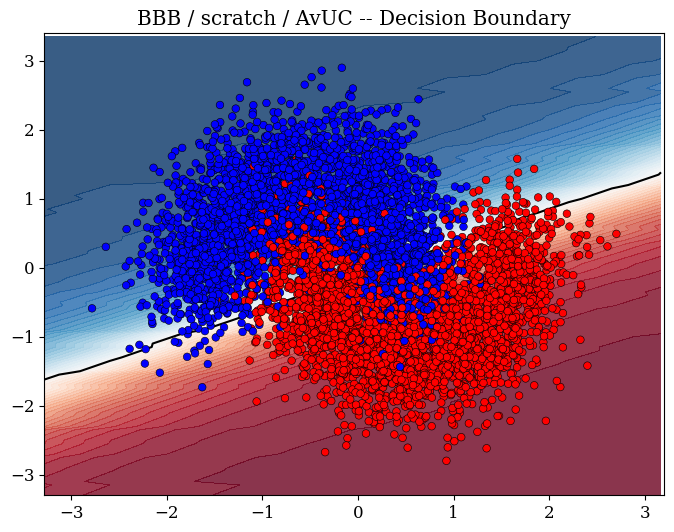

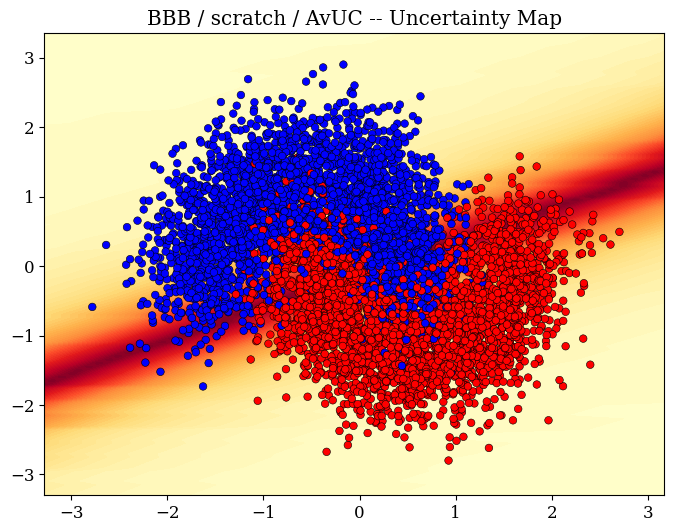

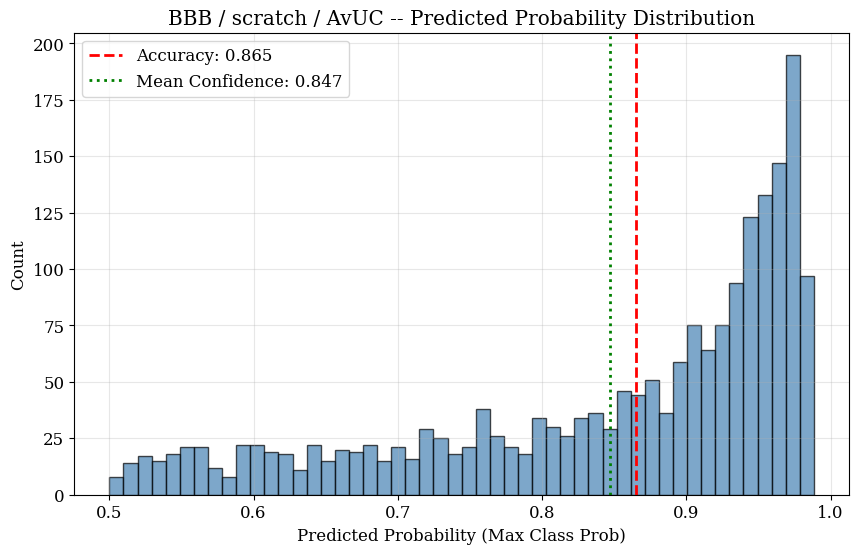

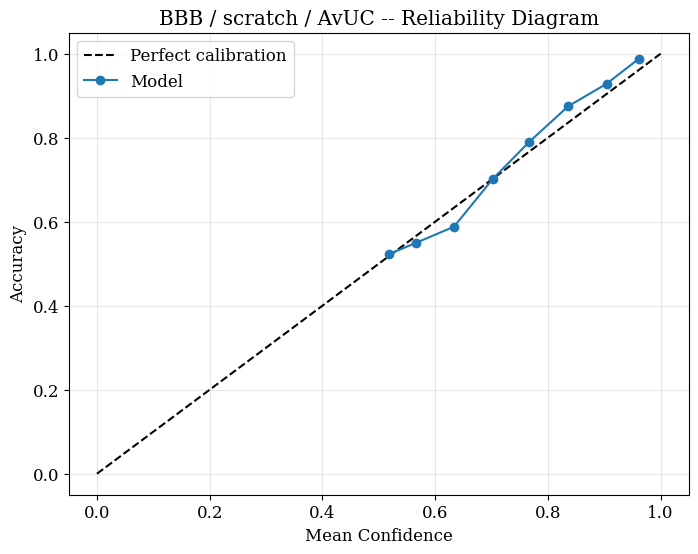

  Saved 4 figures for: bbb_scratch_avuc


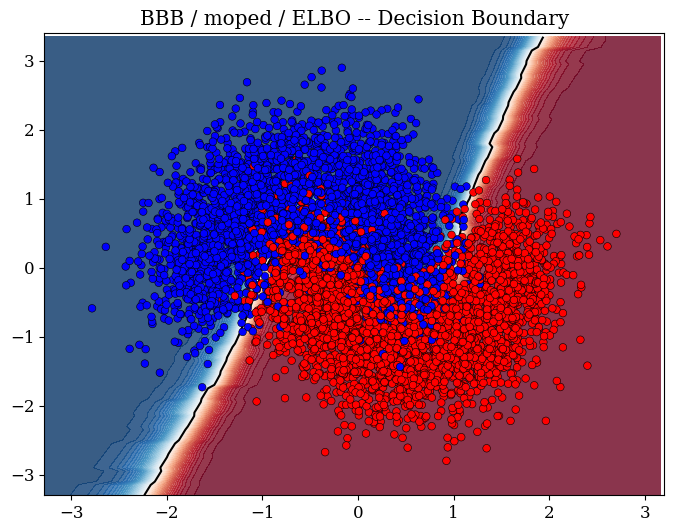

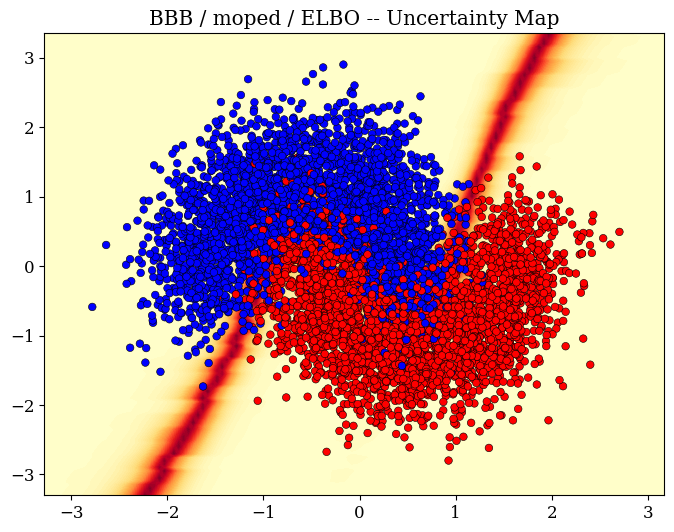

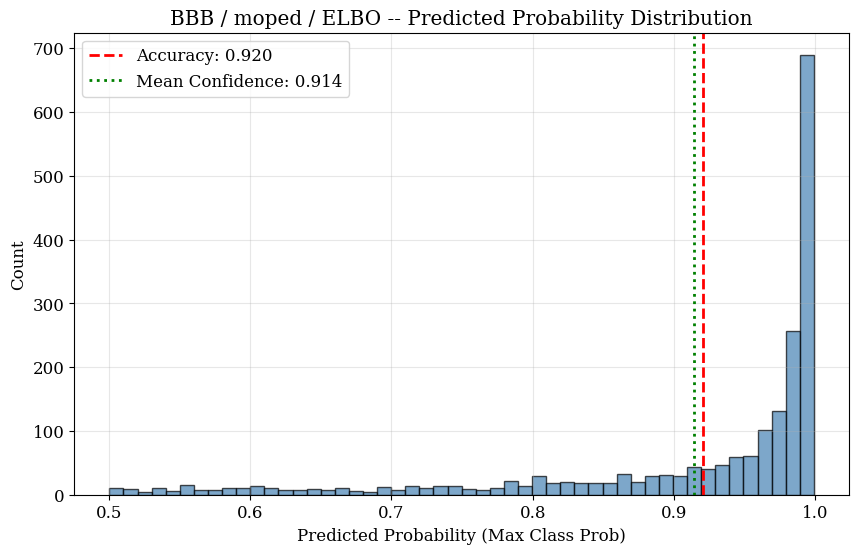

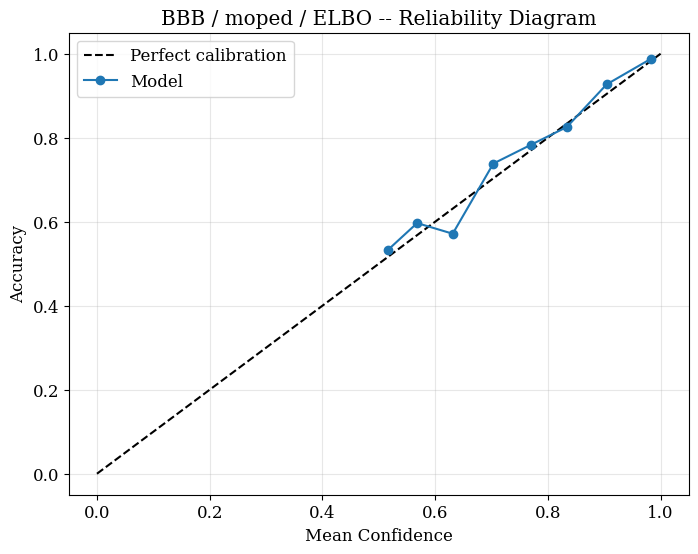

  Saved 4 figures for: bbb_moped_elbo


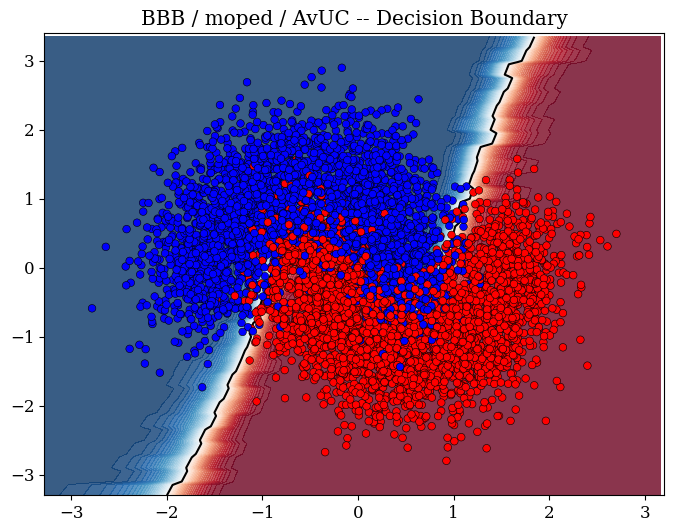

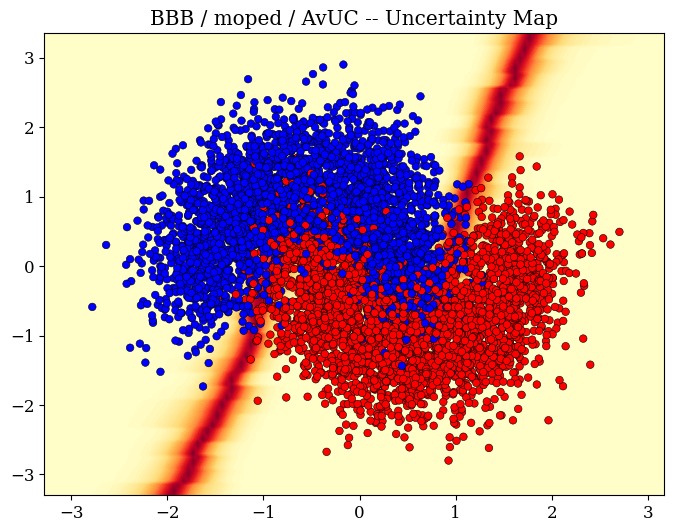

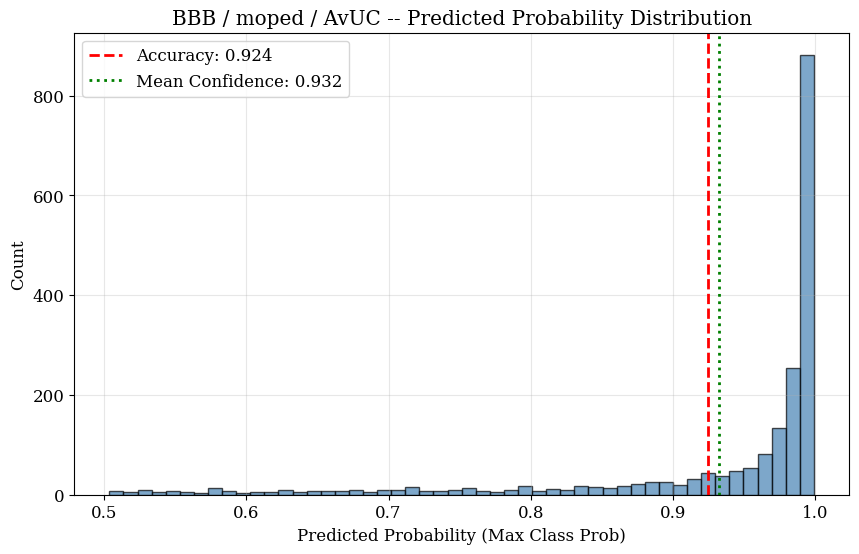

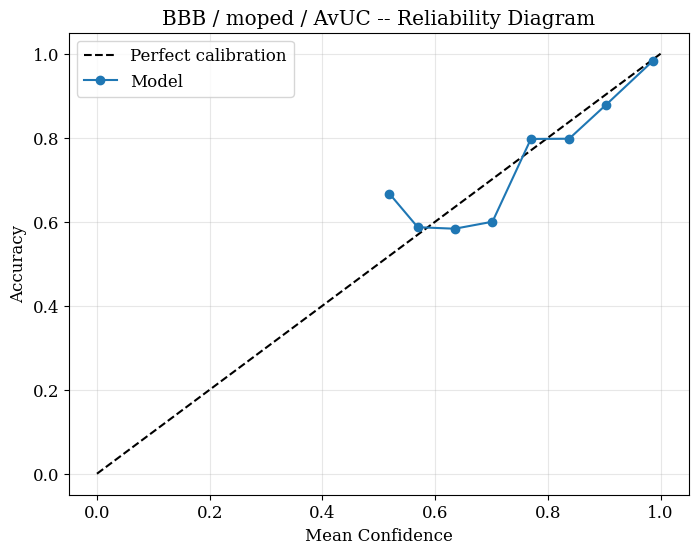

  Saved 4 figures for: bbb_moped_avuc

Done: 32 figures written to ../figures


In [16]:
# Types: decision boundary, uncertainty heatmap, probability histogram, reliability diagram.
for spec in variant_specs:
    vname = spec["variant_name"]
    title = spec["plot_title"]
    res = variant_results[vname]
    net = res["model"]
    test_probs = res["probs"]            # (N_test, 2)

    # 1) Decision boundary
    fig, ax = plt.subplots(1, 1, figsize=(8, 6))
    plot_boundary(lambda X: bnn_predict(X, net), X_train, y_train,
                  f"{title} -- Decision Boundary", ax=ax)
    fig.savefig(os.path.join(FIGURES_DIR, f"{vname}_boundary.png"), dpi=150, bbox_inches="tight")
    plt.show()

    # 2) Uncertainty heatmap
    fig, ax = plt.subplots(1, 1, figsize=(8, 6))
    uncertainty_map(lambda X: bnn_predict(X, net), X_train, y_train,
                    f"{title} -- Uncertainty Map", ax=ax)
    fig.savefig(os.path.join(FIGURES_DIR, f"{vname}_uncertainty.png"), dpi=150, bbox_inches="tight")
    plt.show()

    # 3) Predicted-probability histogram (test set)
    fig, ax = plt.subplots(1, 1, figsize=(10, 6))
    probs_max = test_probs.max(axis=1)
    acc = float((test_probs.argmax(axis=1) == y_test_np).mean())
    mean_conf = float(probs_max.mean())
    ax.hist(probs_max, bins=50, edgecolor="black", alpha=0.7, color="steelblue")
    ax.axvline(x=acc, color="red", linestyle="--", linewidth=2, label=f"Accuracy: {acc:.3f}")
    ax.axvline(x=mean_conf, color="green", linestyle=":", linewidth=2, label=f"Mean Confidence: {mean_conf:.3f}")
    ax.set_xlabel("Predicted Probability (Max Class Prob)")
    ax.set_ylabel("Count")
    ax.set_title(f"{title} -- Predicted Probability Distribution")
    ax.legend()
    ax.grid(True, alpha=0.3)
    fig.savefig(os.path.join(FIGURES_DIR, f"{vname}_histogram.png"), dpi=150, bbox_inches="tight")
    plt.show()

    # 4) Reliability diagram (test set)
    fig, ax = plt.subplots(1, 1, figsize=(8, 6))
    plot_reliability(y_test_np, test_probs, ax, f"{title} -- Reliability Diagram")
    fig.savefig(os.path.join(FIGURES_DIR, f"{vname}_reliability.png"), dpi=150, bbox_inches="tight")
    plt.show()

    print(f"  Saved 4 figures for: {vname}")

print(f"\nDone: {len(variant_specs) * 4} figures written to {FIGURES_DIR}")

In [17]:
# Final exhaustive metrics table
variant_table = variant_eval_df.copy()
variant_table.index.name = 'Model Type'

# Keep a stable column order and include the most useful metrics up front.
preferred_cols = [
    'Model_Type',
    'Init',
    'Loss',
    'Epochs',
    'Best_Val_NLL',
    'LR',
    'Fit_Time (s)',
    'Inf_Time (s)',
    'Accuracy',
    'NLL',
    'Brier_Score',
    'ECE',
    'Mean_Confidence',
    'Mean_Entropy',
    '1 - Confidence',
    'ExpectedVsActual_Uncertainty_MAE',
    'ExpectedVsActual_Uncertainty_MSE',
    'ExpectedVsActual_Uncertainty_Corr',
    'Max_Binned_Uncertainty_Gap',
]
existing_cols = [col for col in preferred_cols if col in variant_table.columns]
remaining_cols = [col for col in variant_table.columns if col not in existing_cols]
variant_table = variant_table[existing_cols + remaining_cols]

variant_display = variant_table.copy()
for col in variant_display.columns:
    if pd.api.types.is_float_dtype(variant_display[col]):
        variant_display[col] = variant_display[col].map(lambda x: f"{x:.4f}" if pd.notna(x) else '-')
    elif pd.api.types.is_integer_dtype(variant_display[col]):
        variant_display[col] = variant_display[col].map(lambda x: str(x) if pd.notna(x) else '-')
    elif pd.api.types.is_bool_dtype(variant_display[col]):
        variant_display[col] = variant_display[col].map(lambda x: 'true' if bool(x) else 'false')

print('Two Moons Bayesian-Torch Variant-Level Calibration and Uncertainty Benchmarks')
display(variant_display)

os.makedirs('results/metrics', exist_ok=True)
variant_csv_path = 'results/metrics/two_moons_bayesian_variant_metrics.csv'
variant_table.to_csv(variant_csv_path)
print(f'\nSaved metrics to {variant_csv_path}')

# Backward-compatible export at the notebook root.
legacy_csv_path = 'twomoons_bayesian_torch_metrics.csv'
variant_table.to_csv(legacy_csv_path)
print(f'Saved metrics to {legacy_csv_path}')

Two Moons Bayesian-Torch Variant-Level Calibration and Uncertainty Benchmarks


,Model_Type,Init,Loss,Epochs,Best_Val_NLL,LR,Fit_Time (s),Inf_Time (s),Accuracy,NLL,...,ECE,Mean_Confidence,Mean_Entropy,1 - Confidence,ExpectedVsActual_Uncertainty_MAE,ExpectedVsActual_Uncertainty_MSE,ExpectedVsActual_Uncertainty_Corr,Max_Binned_Uncertainty_Gap,Classwise_ECE,Mean_Actual_Error
Model Type,,,,,,,,,,,,,,,,,,,,,
Flipout / scratch / ELBO,Flipout,scratch,ELBO,39,0.2479,0.0050,19.0597,0.0947,0.9210,0.1979,...,0.0177,0.9058,0.2407,0.0942,0.0177,0.0005,0.9857,0.0707,0.0177,0.0790
Flipout / scratch / AvUC,Flipout,scratch,ELBO+AvUC,38,0.2560,0.0050,80.3604,0.1019,0.9185,0.1981,...,0.0108,0.9278,0.1843,0.0722,0.0108,0.0004,0.9832,0.0856,0.0108,0.0815
Flipout / moped / ELBO,Flipout,MOPED,ELBO,39,0.2455,0.0050,19.9830,0.0930,0.9150,0.1994,...,0.0147,0.9109,0.2222,0.0891,0.0147,0.0007,0.9773,0.1533,0.0147,0.0850
Flipout / moped / AvUC,Flipout,MOPED,ELBO+AvUC,40,0.2531,0.0050,90.1159,0.1187,0.9225,0.1987,...,0.0114,0.9279,0.1834,0.0721,0.0114,0.0004,0.9516,0.1129,0.0114,0.0775
BBB / scratch / ELBO,Reparameterization,scratch,ELBO,50,0.2457,0.0050,23.2195,0.0622,0.9210,0.1974,...,0.0190,0.9111,0.2291,0.0889,0.0190,0.0006,0.9783,0.0689,0.0190,0.0790
BBB / scratch / AvUC,Reparameterization,scratch,ELBO+AvUC,32,0.3640,0.0050,73.3254,0.0346,0.8650,0.3103,...,0.0254,0.8470,0.3620,0.1530,0.0254,0.0008,0.9938,0.0453,0.0254,0.1350
BBB / moped / ELBO,Reparameterization,MOPED,ELBO,36,0.2448,0.0050,15.8793,0.0350,0.9205,0.1958,...,0.0111,0.9143,0.2148,0.0857,0.0111,0.0003,0.9838,0.0597,0.0111,0.0795
BBB / moped / AvUC,Reparameterization,MOPED,ELBO+AvUC,33,0.2539,0.0050,68.6807,0.0698,0.9245,0.1914,...,0.0140,0.9323,0.1750,0.0677,0.0140,0.0008,0.8937,0.1477,0.0140,0.0755



Saved metrics to results/metrics/two_moons_bayesian_variant_metrics.csv
Saved metrics to twomoons_bayesian_torch_metrics.csv


## Out-of-Distribution (OOD) Test

The two-moons training data spans roughly `x1, x2 ∈ [-2.8, 2.9]`. Here we build a
purely synthetic 2D OOD set clustered around the four far corners `(±3, ±3)` and
evaluate every fitted variant on it.

A well-calibrated Bayesian model should be less confident (higher `1 - Confidence`
and higher entropy) on these OOD points than on the in-distribution test set, a
deterministic MAP net typically stays confidently wrong out there.

OOD set: 200 points around corners [[-3.0, -3.0], [3.0, -3.0], [-3.0, 3.0], [3.0, 3.0]]


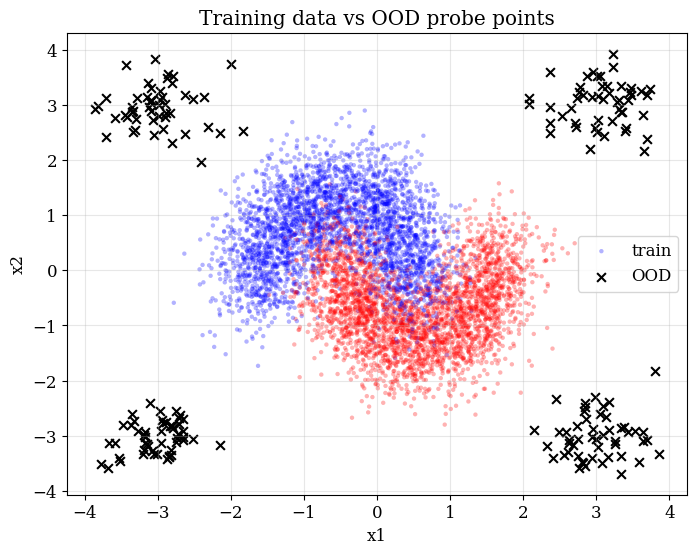

In [18]:
# Build OOD set: 2D points outside the training distribution
rng = np.random.default_rng(SEED)
ood_corners = np.array([[-3, -3], [3, -3], [-3, 3], [3, 3]], dtype=float)
n_per_corner = 50
X_ood = np.vstack([c + 0.4 * rng.standard_normal((n_per_corner, 2)) for c in ood_corners])
print(f"OOD set: {len(X_ood)} points around corners {ood_corners.tolist()}")

# Sanity scatter: training data vs OOD points
fig, ax = plt.subplots(1, 1, figsize=(8, 6))
ax.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap="bwr", s=10, alpha=0.3, edgecolors="none", label="train")
ax.scatter(X_ood[:, 0], X_ood[:, 1], c="black", marker="x", s=40, label="OOD")
ax.set_title("Training data vs OOD probe points")
ax.set_xlabel("x1"); ax.set_ylabel("x2")
ax.legend(); ax.grid(True, alpha=0.3)
fig.savefig(os.path.join(FIGURES_DIR, "ood_points.png"), dpi=150, bbox_inches="tight")
plt.show()

In [19]:
# ID vs OOD uncertainty per variant (epistemic/aleatoric decomposition)
def _entropy(p):
    return -(p * np.log(p + 1e-12)).sum(axis=-1)

def predictive_uncertainties(model, X_np, n_samples=100, batch_size=512):
    """Per-point (confidence, total, aleatoric, epistemic) via MC weight sampling.
    epistemic = mutual information = H[E_θ p] - E_θ[H[p]]."""
    samples = bnn_predict_samples(X_np, model, n_samples=n_samples, batch_size=batch_size)  # (S, N, C)
    mean_p = samples.mean(axis=0)                       # (N, C)
    total = _entropy(mean_p)                             # (N,)
    aleatoric = _entropy(samples).mean(axis=0)          # (N,)
    epistemic = total - aleatoric                        # (N,)  mutual information
    conf = mean_p.max(axis=1)                            # (N,)
    return conf, total, aleatoric, epistemic

ood_rows = []
for spec in variant_specs:
    vname = spec["variant_name"]
    net = variant_results[vname]["model"]

    id_conf,  _, id_alea,  id_epi  = predictive_uncertainties(net, X_test)
    ood_conf, _, ood_alea, ood_epi = predictive_uncertainties(net, X_ood)

    ood_rows.append({
        "ID 1 - Confidence":   float((1 - id_conf).mean()),
        "OOD 1 - Confidence":  float((1 - ood_conf).mean()),
        "ID Aleatoric":        float(id_alea.mean()),
        "OOD Aleatoric":       float(ood_alea.mean()),
        "ID Epistemic":        float(id_epi.mean()),
        "OOD Epistemic":       float(ood_epi.mean()),
        "Δ Epistemic (OOD-ID)": float(ood_epi.mean() - id_epi.mean()),
    })

ood_df = pd.DataFrame(ood_rows, index=[s["plot_title"] for s in variant_specs])
ood_df.index.name = "Variant"
print("ID vs OOD: Epistemic should be higher on OOD (Δ Epistemic > 0)")
display(ood_df.round(4))

os.makedirs("results/metrics", exist_ok=True)
ood_df.to_csv("results/metrics/two_moons_bayesian_ood_metrics.csv")
print("\nSaved OOD metrics to results/metrics/two_moons_bayesian_ood_metrics.csv")

ID vs OOD: Epistemic should be higher on OOD (Δ Epistemic > 0)


,ID 1 - Confidence,OOD 1 - Confidence,ID Aleatoric,OOD Aleatoric,ID Epistemic,OOD Epistemic,Δ Epistemic (OOD-ID)
Variant,,,,,,,
Flipout / scratch / ELBO,0.0943,0.0052,0.2380,0.0280,0.0030,0.0005,-0.0025
Flipout / scratch / AvUC,0.0722,0.0025,0.1762,0.0117,0.0076,0.0009,-0.0067
Flipout / moped / ELBO,0.0893,0.0097,0.2130,0.0341,0.0095,0.0028,-0.0067
Flipout / moped / AvUC,0.0726,0.0048,0.1489,0.0190,0.0357,0.0046,-0.0310
BBB / scratch / ELBO,0.0887,0.0027,0.2258,0.0172,0.0026,0.0002,-0.0024
BBB / scratch / AvUC,0.1520,0.0318,0.3571,0.1243,0.0031,0.0018,-0.0013
BBB / moped / ELBO,0.0874,0.0112,0.2047,0.0398,0.0140,0.0062,-0.0078
BBB / moped / AvUC,0.0659,0.0055,0.1395,0.0234,0.0319,0.0047,-0.0271



Saved OOD metrics to results/metrics/two_moons_bayesian_ood_metrics.csv


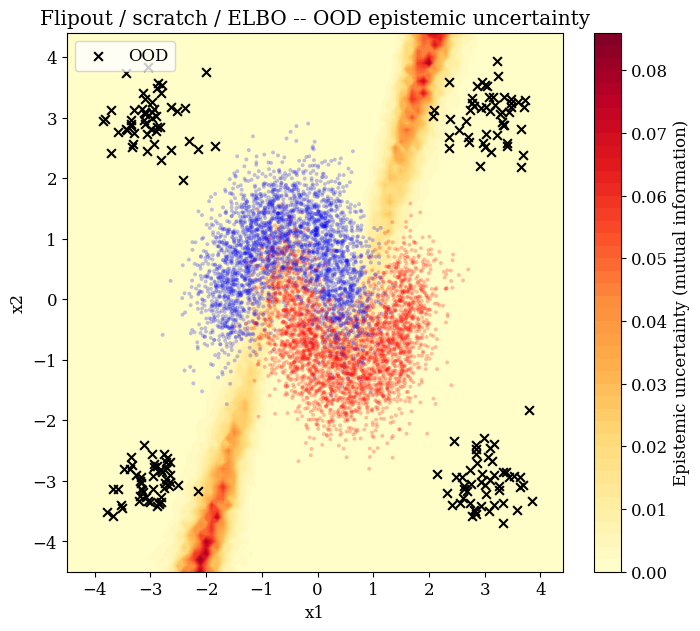

  Saved OOD epistemic map for: flipout_scratch_elbo


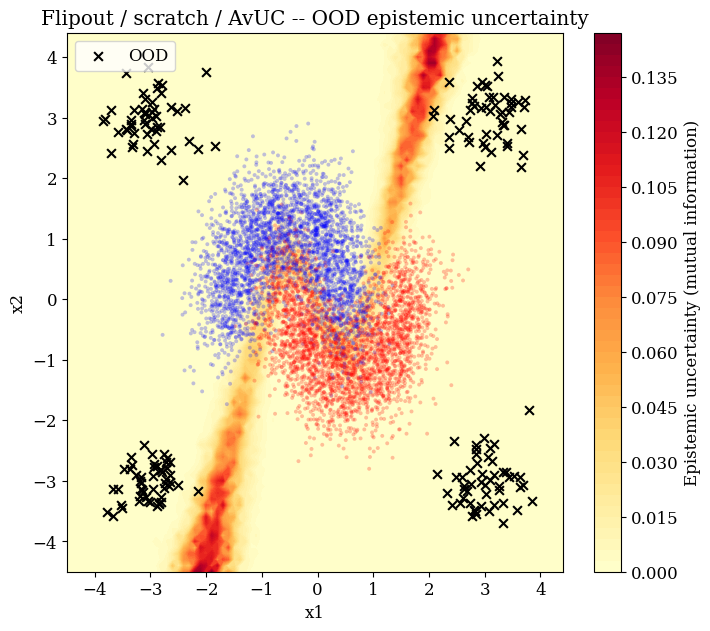

  Saved OOD epistemic map for: flipout_scratch_avuc


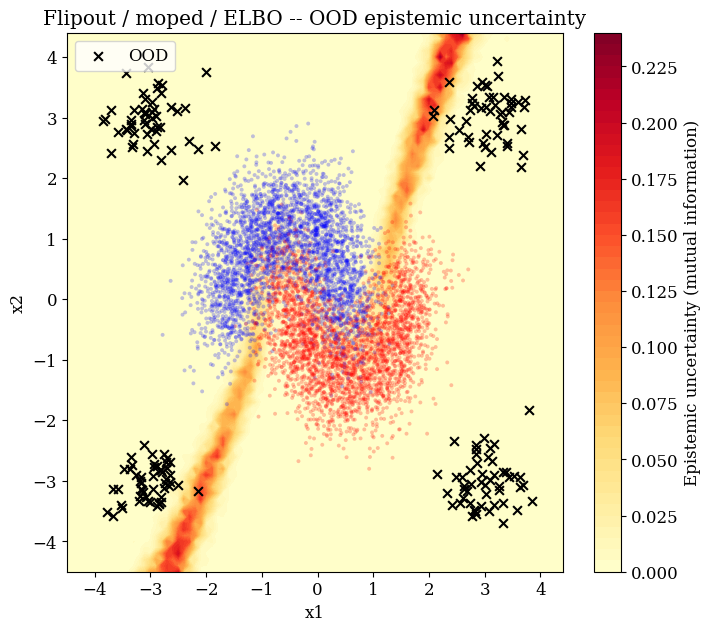

  Saved OOD epistemic map for: flipout_moped_elbo


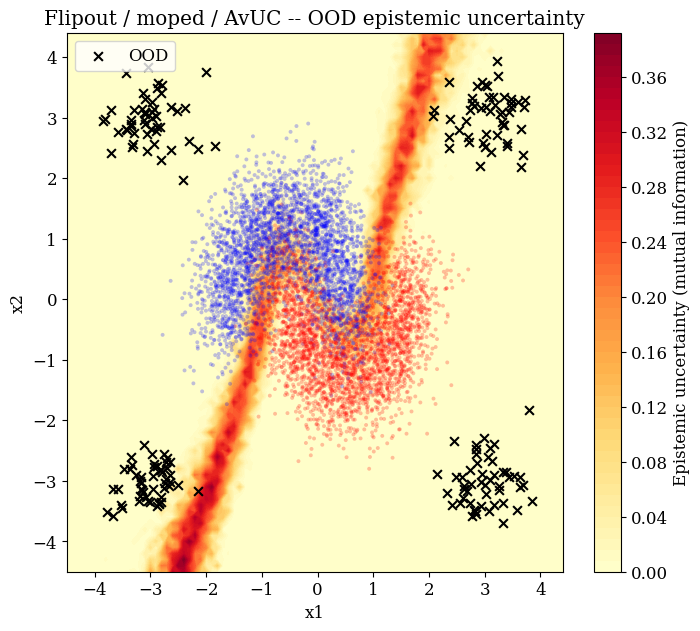

  Saved OOD epistemic map for: flipout_moped_avuc


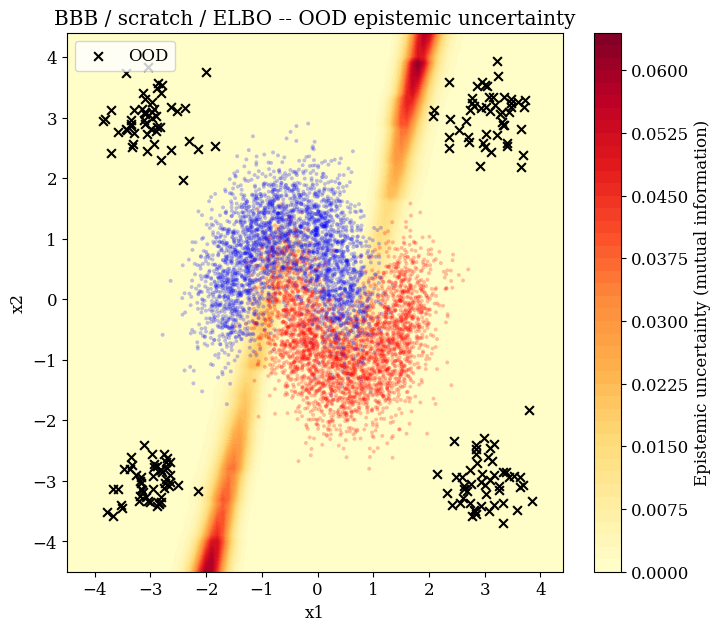

  Saved OOD epistemic map for: bbb_scratch_elbo


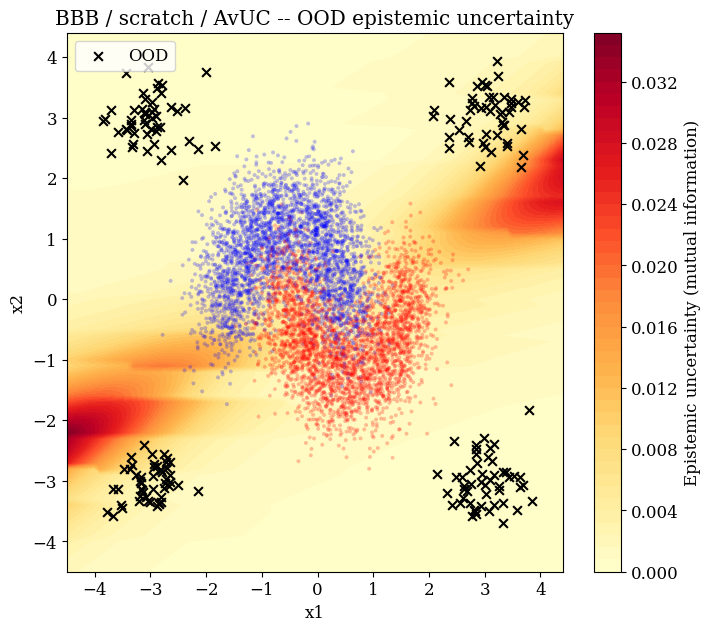

  Saved OOD epistemic map for: bbb_scratch_avuc


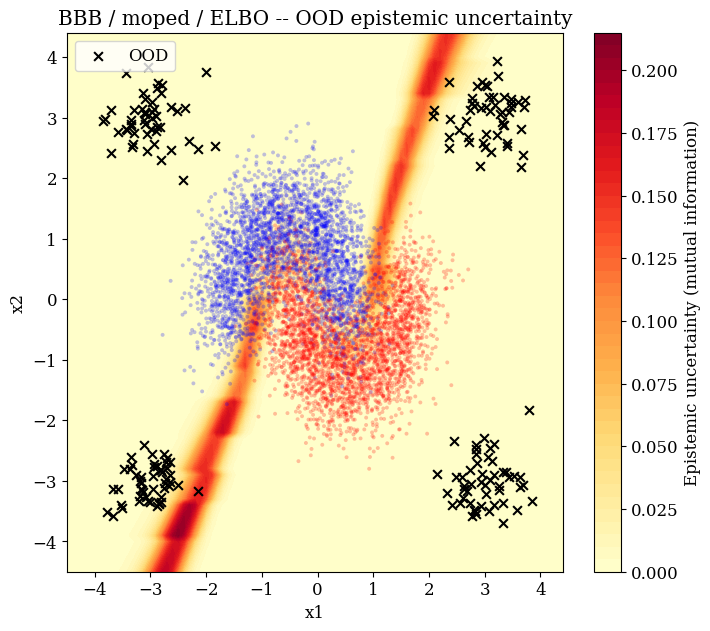

  Saved OOD epistemic map for: bbb_moped_elbo


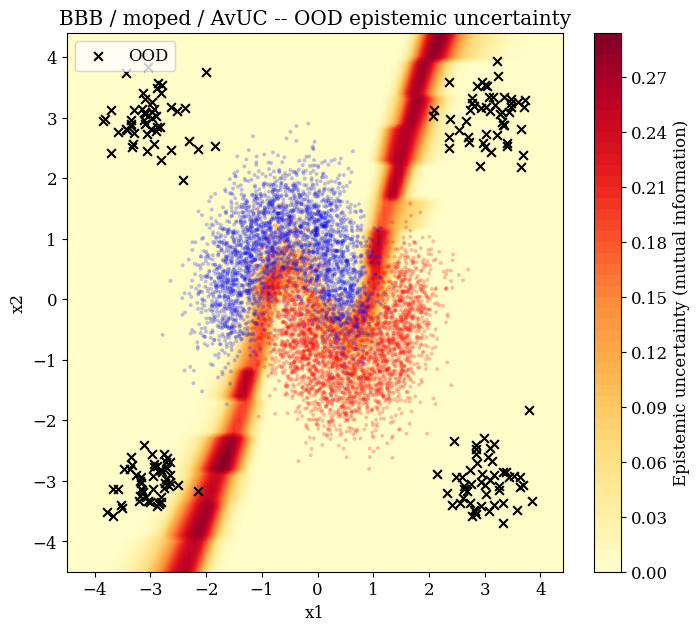

  Saved OOD epistemic map for: bbb_moped_avuc

Done: 8 OOD epistemic maps written to ../figures


In [20]:
# Per-variant OOD EPISTEMIC-uncertainty maps (extended grid)
ext = 4.5
gx, gy = np.meshgrid(np.arange(-ext, ext, 0.1), np.arange(-ext, ext, 0.1))
ood_grid = np.c_[gx.ravel(), gy.ravel()]

for spec in variant_specs:
    vname = spec["variant_name"]; title = spec["plot_title"]
    net = variant_results[vname]["model"]
    _, _, _, epi = predictive_uncertainties(net, ood_grid, n_samples=50)
    epi_grid = epi.reshape(gx.shape)

    fig, ax = plt.subplots(1, 1, figsize=(8, 7))
    cf = ax.contourf(gx, gy, epi_grid, levels=50, cmap="YlOrRd")
    ax.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap="bwr", s=8, alpha=0.25, edgecolors="none")
    ax.scatter(X_ood[:, 0], X_ood[:, 1], c="black", marker="x", s=40, label="OOD")
    plt.colorbar(cf, ax=ax, label="Epistemic uncertainty (mutual information)")
    ax.set_title(f"{title} -- OOD epistemic uncertainty")
    ax.set_xlabel("x1"); ax.set_ylabel("x2")
    ax.legend(loc="upper left")
    fig.savefig(os.path.join(FIGURES_DIR, f"{vname}_ood_epistemic.png"), dpi=150, bbox_inches="tight")
    plt.show()
    print(f"  Saved OOD epistemic map for: {vname}")

print(f"\nDone: {len(variant_specs)} OOD epistemic maps written to {FIGURES_DIR}")

In [ ]:
# k-NN prediction-averaging uncertainty scatter
# For each test point, smooth the model's predicted class-1 probability
# over its k=5 nearest neighbors in X_test, then color by 1 - max(p_smooth, 1-p_smooth).
k = 5
dists = np.linalg.norm(X_test[:, None] - X_test[None, :], axis=-1)  # (N, N)
np.fill_diagonal(dists, np.inf)
nn_idx = np.argsort(dists, axis=1)[:, :k]  # (N, k) — indices of k nearest neighbors

for spec in variant_specs:
    vname = spec["variant_name"]
    title = spec["plot_title"]
    probs = variant_results[vname]["probs"]  # (N, 2)
    p = probs[:, 1]                          # class-1 probability per test point
    p_smooth = p[nn_idx].mean(axis=1)        # average over k nearest neighbors
    uncertainty = 1 - np.maximum(p_smooth, 1 - p_smooth)

    fig, ax = plt.subplots(1, 1, figsize=(8, 6))
    sc = ax.scatter(X_test[:, 0], X_test[:, 1], c=uncertainty,
                    cmap="YlOrRd", vmin=0, vmax=0.5, s=30, edgecolors="k", linewidths=0.3)
    plt.colorbar(sc, ax=ax, label="k-NN smoothed uncertainty  (1 − max(p, 1−p))")
    ax.set_title(f"{title} — k-NN Prediction-Averaged Uncertainty  (k={k})")
    ax.set_xlabel("x1"); ax.set_ylabel("x2")
    ax.grid(True, alpha=0.3)
    fname = f"{vname}_knn_uncertainty.png"
    fig.savefig(os.path.join(FIGURES_DIR, fname), dpi=150, bbox_inches="tight")
    plt.show()
    print(f"  Saved: {fname}")
print(f"\nDone: {len(variant_specs)} k-NN uncertainty scatter figures")
